## Data Preparation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import sys
import os
sys.path.append(os.path.abspath("..")) 
from Datasets_n_simulator.simulator import simulate
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline


In [ ]:
infected_df = pd.read_csv("../Datasets_n_simulator/infected_timeseries.csv")
rewiring_df = pd.read_csv("../Datasets_n_simulator/rewiring_timeseries.csv")
degree_df = pd.read_csv("../Datasets_n_simulator/final_degree_histograms.csv")


In [ ]:
infected_df = infected_df[infected_df["replicate_id"] == 0]
rewiring_df = rewiring_df[rewiring_df["replicate_id"] == 0]
degree_df = degree_df[degree_df["replicate_id"] == 0]
obs_infected = infected_df["infected_fraction"].values
obs_rewiring = rewiring_df["rewire_count"].values
obs_degree = degree_df["count"].values

In [ ]:
def sample_prior(rng):
    beta = rng.uniform(0.05, 0.5)
    gamma = rng.uniform(0.02, 0.2)
    rho = rng.uniform(0.0, 0.8)
    return beta, gamma, rho

In [ ]:
def compute_distances(summaries, s_obs):
    #std = np.std(summaries, axis=0) + 1e-8
    dist = np.linalg.norm((summaries - s_obs), axis=1)
    return dist

In [ ]:
def rejection_abc_quantile(n_samples, s_obs, rng):
    thetas = []
    summaries = []

    for _ in range(n_samples):
        theta = sample_prior(rng)
        infected, rewiring, degree = simulate(*theta, rng=rng)

        s_sim = compute_summary(infected, rewiring, degree)

        thetas.append(theta)
        summaries.append(s_sim)

    thetas = np.array(thetas)           # shape (n, 3)
    summaries = np.array(summaries)     # shape (n, k)

    return thetas, summaries

In [ ]:
def select_accepted(thetas, distances, quantile=0.05):
    epsilon = np.quantile(distances, quantile)

    indices = np.where(distances <= epsilon)[0]

    accepted_thetas = thetas[indices]

    return accepted_thetas, epsilon

In [ ]:
rng = np.random.default_rng(42)
theta = sample_prior(rng)

In [ ]:
def simulate_replicates(theta, R=40, rng=None):
    summaries = []
    for _ in range(R):
        infected, rewiring, degree = simulate(*theta, rng=rng)
        summaries.append(compute_summary(infected, rewiring, degree))
    return np.mean(summaries, axis=0)

In [ ]:
# histogram plots of beta, rho, gamma
def plot_marginals(samples):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    # Means
    mean_beta = np.mean(beta)
    mean_gamma = np.mean(gamma)
    mean_rho = np.mean(rho)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot histograms and add mean lines
    axes[0].hist(beta, bins=30, color='skyblue', edgecolor='black')
    axes[0].axvline(mean_beta, color='red', linestyle='dashed', linewidth=2)
    axes[0].set_title(f"Posterior of β\nMean = {mean_beta:.2f}")

    axes[1].hist(gamma, bins=30, color='skyblue', edgecolor='black')
    axes[1].axvline(mean_gamma, color='red', linestyle='dashed', linewidth=2)
    axes[1].set_title(f"Posterior of γ\nMean = {mean_gamma:.2f}")

    axes[2].hist(rho, bins=30, color='skyblue', edgecolor='black')
    axes[2].axvline(mean_rho, color='red', linestyle='dashed', linewidth=2)
    axes[2].set_title(f"Posterior of ρ\nMean = {mean_rho:.2f}")

    plt.tight_layout()
    plt.show()

In [ ]:
# pairwise scatter plot
def plot_pairwise(samples):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(beta, gamma, alpha=0.5)
    axes[0].set_xlabel("β")
    axes[0].set_ylabel("γ")
    axes[0].set_title("β vs γ")

    axes[1].scatter(beta, rho, alpha=0.5)
    axes[1].set_xlabel("β")
    axes[1].set_ylabel("ρ")
    axes[1].set_title("β vs ρ")

    axes[2].scatter(gamma, rho, alpha=0.5)
    axes[2].set_xlabel("γ")
    axes[2].set_ylabel("ρ")
    axes[2].set_title("γ vs ρ")

    plt.tight_layout()
    plt.show()

In [ ]:
#summary stats: 6
def compute_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)
    #rewiring_timing = np.argmax(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring
    ])

In [ ]:
s_obs = compute_summary(obs_infected, obs_rewiring, obs_degree)
s_obs

array([5.400e-01, 9.000e+00, 0.000e+00, 9.905e+00, 5.820e+02, 9.700e+01])

In [ ]:
s_sim = simulate_replicates(theta, R=40, rng=rng)

In [ ]:
thetas, summaries = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s_obs,
    rng=rng
)

In [ ]:
scaler = StandardScaler()

summaries_scaled = scaler.fit_transform(summaries)

s_obs_scaled = scaler.transform(s_obs.reshape(1, -1))[0]

In [ ]:
dists = np.linalg.norm(summaries_scaled - s_obs_scaled, axis=1)
samples, epsilon = select_accepted(
    thetas,
    dists,
    quantile=0.05
)


print("Accepted samples:", samples.shape)
print("Epsilon used:", epsilon)

Accepted samples: (1000, 3)
Epsilon used: 0.9490866947605033


## Regression Adjustment ABC Implementation

In [ ]:
accepted_idx = dists <= epsilon
accepted_thetas = thetas[accepted_idx]
accepted_summaries = summaries_scaled[accepted_idx]
accepted_dists = dists[accepted_idx]

In [ ]:
def regression_adjustment(accepted_thetas, accepted_summaries, s_obs_scaled, accepted_dists, epsilon):

    weights = 1 - (accepted_dists / epsilon)**2
    weights = np.clip(weights, 0, None)

    delta = accepted_summaries - s_obs_scaled    

    adjusted_params = np.zeros_like(accepted_thetas)

    for j in range(accepted_thetas.shape[1]):
        reg = LinearRegression()
        reg.fit(delta, accepted_thetas[:, j], sample_weight=weights)

        beta_hat = reg.coef_

        adjusted_params[:, j] = accepted_thetas[:, j] - delta @ beta_hat

    return adjusted_params

In [ ]:
adjusted_params = regression_adjustment(
    samples,
    accepted_summaries,
    s_obs_scaled,
    accepted_dists,
    epsilon
)

In [ ]:
#std

def compare_std(samples, adjusted_params):
    labels = ["β", "γ", "ρ"]

    for j in range(3):
        std_before = np.std(samples[:, j])
        std_after = np.std(adjusted_params[:, j])

        print(labels[j])
        print("Before:", std_before)
        print("After :", std_after)
        print("Change:", std_after - std_before)
        print()

In [ ]:
compare_std(samples, adjusted_params)

β
Before: 0.058127794412568816
After : 0.0345545302938735
Change: -0.023573264118695314

γ
Before: 0.033588586690082925
After : 0.011970281041959033
Change: -0.021618305648123892

ρ
Before: 0.09461831092993556
After : 0.041021362471216787
Change: -0.05359694845871877



In [ ]:


def evaluate_results(thetas, summaries):
    model = make_pipeline(
        StandardScaler(),
        LinearRegression()
    )

    scores = cross_val_score(
        model,
        summaries,
        thetas,
        scoring='neg_mean_squared_error',
        cv=5
    )

    return -scores.mean(), scores.std()

In [ ]:
print("Before:", evaluate_results(samples, accepted_summaries))
print("After :", evaluate_results(adjusted_params, accepted_summaries))

Before: (np.float64(0.0010180043521684904), np.float64(7.439393365527339e-05))
After : (np.float64(0.0010180043521684906), np.float64(7.439393365527331e-05))


In [ ]:
# mean

for j, name in enumerate(["β","γ","ρ"]):
    print(name)
    print("Before:", np.mean(samples[:, j]))
    print("After :", np.mean(adjusted_params[:, j]))
    print()

β
Before: 0.20044278372530822
After : 0.1528009260666128

γ
Before: 0.12821112519893774
After : 0.09845128515781423

ρ
Before: 0.3698124481532647
After : 0.3215076328255961



In [ ]:
np.allclose(samples, adjusted_params)

False

In [ ]:
# range

for j, name in enumerate(["β","γ","ρ"]):
    print(name)
    print("Before:", np.min(samples[:, j]), np.max(samples[:, j]))
    print("After :", np.min(adjusted_params[:, j]), np.max(adjusted_params[:, j]))
    print()

β
Before: 0.07343670274598321 0.412337020052026
After : 0.05640216302019668 0.2990573214254231

γ
Before: 0.0604280874393793 0.19849077003688595
After : 0.06123970272517629 0.1359358093752328

ρ
Before: 0.13622020562454198 0.6633244540581217
After : 0.20421100287908578 0.4792318174826557



In [ ]:
np.mean(np.abs(adjusted_params - samples))

np.float64(0.058967828789825566)

## Plots

In [ ]:


def scatter_rejection_vs_regression(samples, adjusted_params):

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    pairs = [(0,1), (0,2), (1,2)]
    labels = [("β","γ"), ("β","ρ"), ("γ","ρ")]

    for ax, (i,j), (xlab, ylab) in zip(axes, pairs, labels):

        # Rejection
        ax.scatter(samples[:, i], samples[:, j],
                   alpha=0.4, s=15, label="Rejection ABC")

        # Regression
        ax.scatter(adjusted_params[:, i], adjusted_params[:, j],
                   alpha=0.4, s=15, label="Regression Adj")

        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        ax.set_title(f"{xlab} vs {ylab}")

    axes[0].legend()
    plt.tight_layout()
    plt.show()



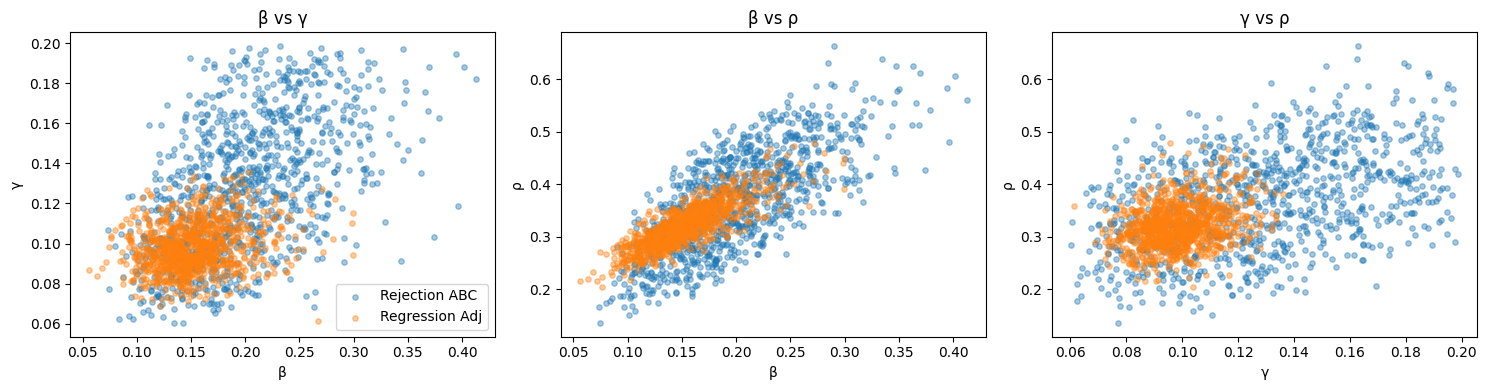

In [ ]:
scatter_rejection_vs_regression(samples, adjusted_params)

In [ ]:
def compare_rejection_vs_regression(samples, adjusted_params):

    # --- Step 1: match sample sizes
    n = min(len(samples), len(adjusted_params))
    samples = samples[:n]
    adjusted_params = adjusted_params[:n]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    param_names = ["β", "γ", "ρ"]

    y_max_global = 0
    hist_data = []

    # --- Step 2: precompute histograms
    for j in range(3):

        all_vals = np.concatenate([samples[:, j], adjusted_params[:, j]])
        bins = np.linspace(all_vals.min(), all_vals.max(), 40)

        hist_s, _ = np.histogram(samples[:, j], bins=bins, density=True)
        hist_r, _ = np.histogram(adjusted_params[:, j], bins=bins, density=True)

        y_max = max(hist_s.max(), hist_r.max())
        y_max_global = max(y_max_global, y_max)

        hist_data.append((bins, hist_s, hist_r))

    # --- Step 3: plot
    for j in range(3):

        bins, _, _ = hist_data[j]

        axes[j].hist(samples[:, j], bins=bins, alpha=0.5,
                     label="Rejection ABC", density=True)

        axes[j].hist(adjusted_params[:, j], bins=bins, alpha=0.5,
                     label="Regression Adj", density=True)

        axes[j].axvline(np.mean(samples[:, j]), linestyle="--", linewidth=1)
        axes[j].axvline(np.mean(adjusted_params[:, j]), linestyle="--", linewidth=1)

        axes[j].set_ylim(0, y_max_global * 1.1)

        axes[j].set_title(f"{param_names[j]} Posterior")
        axes[j].legend()

    plt.tight_layout()
    plt.show()

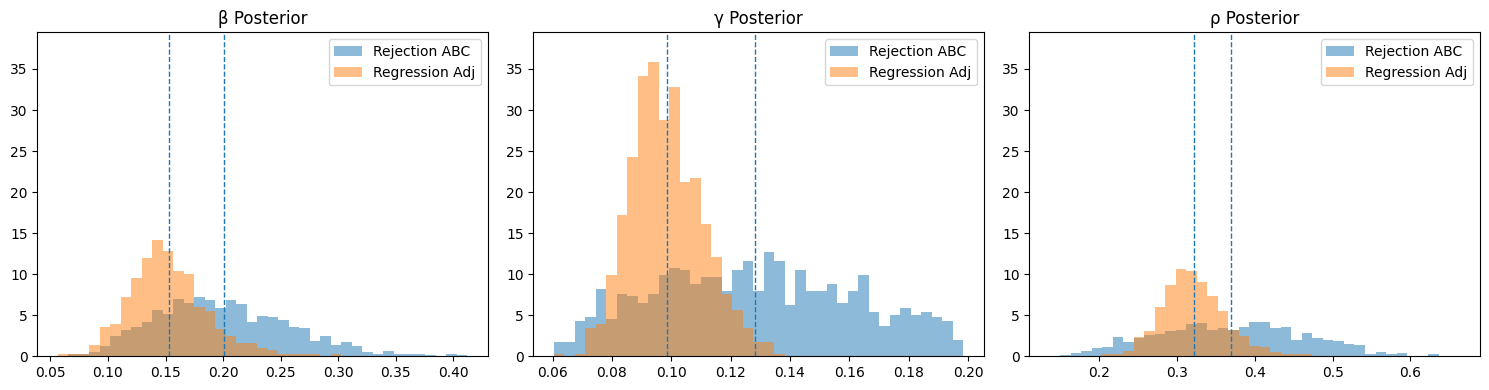

In [ ]:
compare_rejection_vs_regression(samples, adjusted_params)
